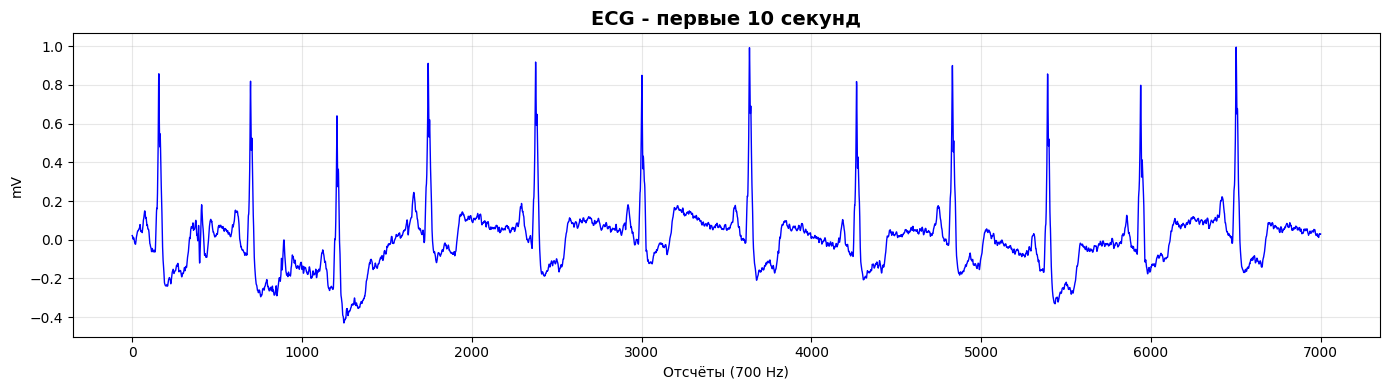

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('outputs', exist_ok=True)

with open('model/wesad/S2/S2.pkl', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

ecg = data['signal']['chest']['ECG'].flatten()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ecg[:7000], linewidth=1, color='blue')
ax.set_title('ECG - первые 10 секунд', fontsize=14, fontweight='bold')
ax.set_ylabel('mV')
ax.set_xlabel('Отсчёты (700 Hz)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/ecg_10sec.png', dpi=150)
plt.show()


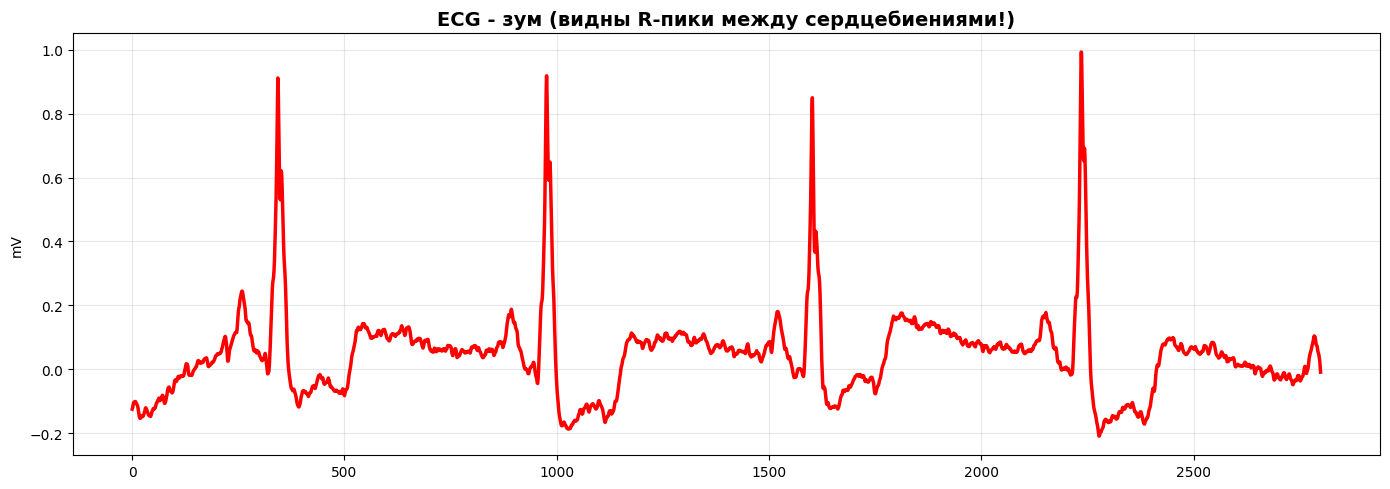

In [3]:
# ГРАФИК 2: Зум на 3 сек (видны R-пики!)
ecg_zoom = ecg[1400:4200]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ecg_zoom, linewidth=2.5, color='red')
ax.set_title('ECG - зум (видны R-пики между сердцебиениями!)', fontsize=14, fontweight='bold')
ax.set_ylabel('mV')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/ecg_zoom.png', dpi=150)
plt.show()

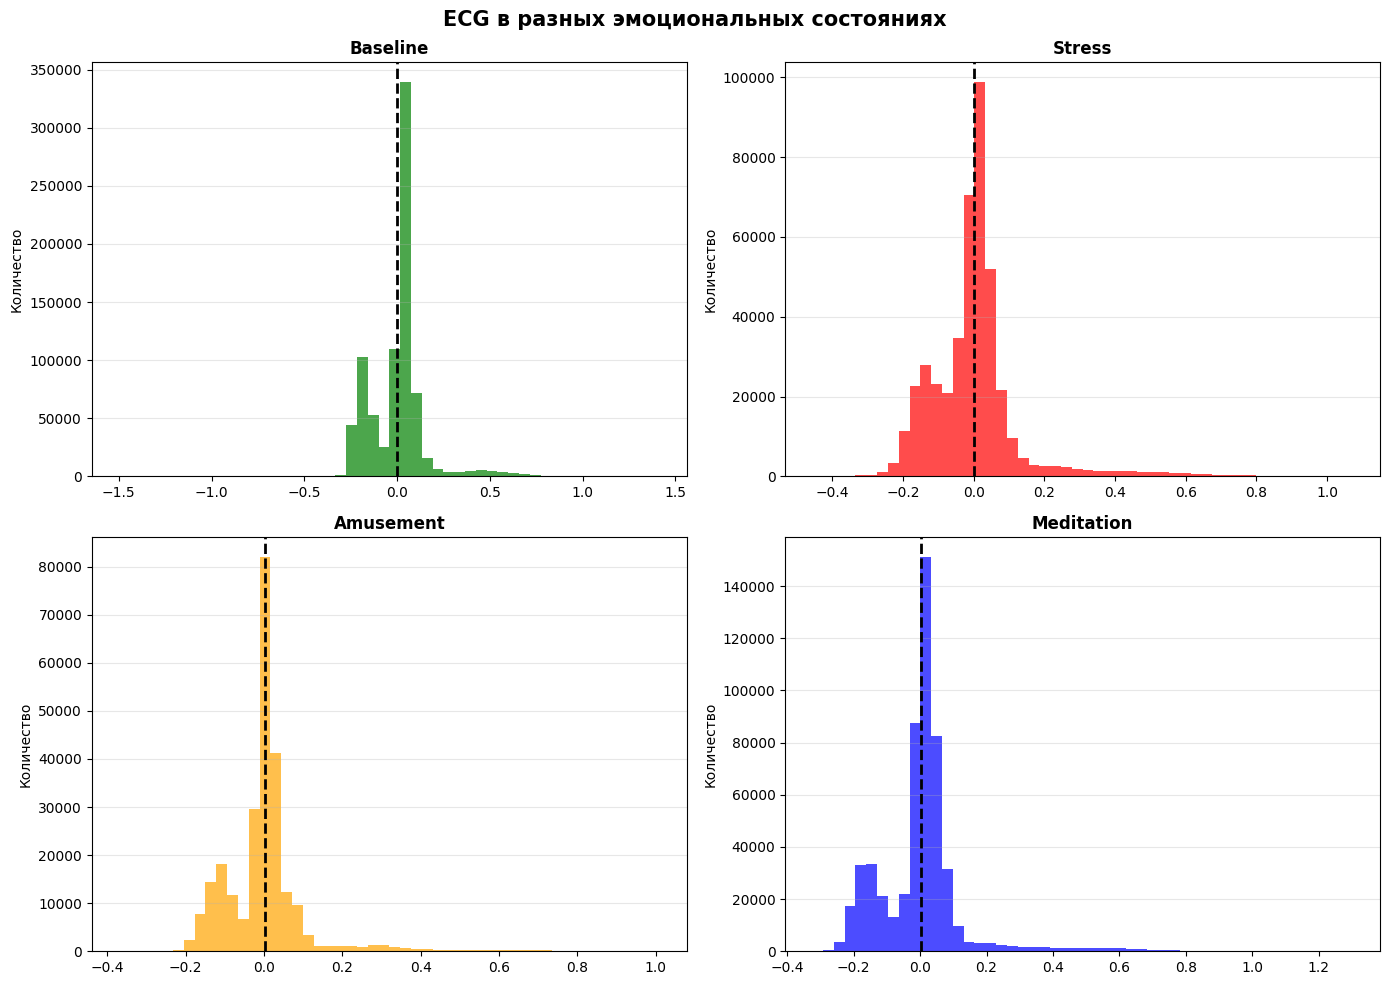

In [4]:
# ГРАФИК 3: Все 4 эмоции
labels = data['label'].flatten()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, emotion_id in enumerate([1, 2, 3, 4]):
    emotion_ecg = ecg[labels == emotion_id]
    emotions = ['Baseline', 'Stress', 'Amusement', 'Meditation']
    colors = ['green', 'red', 'orange', 'blue']
    
    axes[idx].hist(emotion_ecg, bins=50, color=colors[idx], alpha=0.7)
    axes[idx].set_title(emotions[idx], fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Количество')
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    mean = np.mean(emotion_ecg)
    axes[idx].axvline(mean, color='black', linestyle='--', linewidth=2)

plt.suptitle('ECG в разных эмоциональных состояниях', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/ecg_emotions.png', dpi=150)
plt.show()
